In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal, List
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv()

class Classifier(BaseModel):
    """classify complaints into groups"""
    category: Literal["billing","technical","refund","account","general"]
    confidence: int = Field(description="How confidence are you of your categorization 0-10", ge=0, le=10)

class SupportState(TypedDict):
    customer_query: str 
    query_category: str 
    response: str
    tools_used: List[str]


llm = ChatOpenAI(model="gpt-4o-mini")
#router node 
def classify_query(state:SupportState)->SupportState:
    """ classify the category"""

    structured_llm = llm.with_structured_output(Classifier)
    prompt = f"""
    Classify the following customer support query into one of these categories

    - Billing: Questions about invoices, payments, charges, pricing
    - Technical: Tehnical issues, feature problems,integration issues
    - Refund: Refund request, returns, cancellation
    - Account: Account access, password reset, profile changes, login issues
    - General: General questions, feature inquiries, information requests

    Customer Query: {state['customer_query']}

    Classify accurately based on the primary intent
    """

    response = structured_llm.invoke(prompt)

    print("Category", response.category)
    print("How Sure are you 1 - 10", response.confidence)

    return {
        "query_category": response.category
    }


#Handle Billing

def handle_billing(state):
    """Handle billing request"""

    print(" BILLING HANDLER: Processing billing query ")

    prompt = f"""
    You are a billing specialist. Handle this customer query

    {state['customer_query']}

    Provide a helpful response that:
    - References billing policies and procedures
    - Offers to check their account details
    - Provides clear next steps
    - Mentions relevant payment options

    Keep it professional and reassuring
    """

    response = llm.invoke(prompt).content

    return {

        "response": response,
        "tools_used": ["billing_engine","billing database"]
    }

# Handle Technical Support
def handle_technical(state:SupportState)->SupportState:
    """Handle Technical Support"""

    print(" TECHNICAL HANDLER: Processing technical query ")

    prompt = f"""
     You are a technical support specialist. Handle this customer query.

     {state['customer_query']}

    Provide a helpful response that:
    - Offers specific troubleshooting steps
    - References relevant documentation
    - Asks clarifying questions if needed
    - Provides workarounds if applicable

    Be clear and technical but accessible
    """

    response = llm.invoke(prompt).content 

    return {
        "response":response,
        "tools_used":  ["knowledge_base","bug_tracker","system_log"]
    }


def handle_refund(state:SupportState)->SupportState:
    """Handle Refund Support"""

    print(" REFUND HANDLER: Processing refund query ")

    prompt = f"""
      You are a refund specialist. Handle this customer query:

      {state['customer_query']}

    Provide a helpful response that:
    - Explains the refund policy clearly.
    - Outlines the refund process and timeline
    - Asks for necessary information (order number, reason, etc.)
    - Shows empathy and understanding

    Be emphatic and solution-focused
    """

    response = llm.invoke(prompt).content 

    return {
        "response":response,
        "tools_used":  ["order_database","refund_processor"]
    }


def handle_account(state:SupportState)->SupportState:
    """Handle system account related issues"""

    print(" ACCOUNT HANDLER: Processing account query ")

    prompt = f"""
      You are a system account specialist. Handle this customer query:

      {state['customer_query']}
    Account access, password reset, profile changes, login issues
    Provide a helpful response that:
    - Explains Account Access Policy appropriately.
    - Give reason why an account may be locked out
    - Direct to processess of unlocking account. Provide site link to steps to follow
    - Ask basic account access mistakes that user may be making
    - Tell user that account will be reset by admin in 24hrs if issue is complex

    Be emphatic and solution-focused
    """

    response = llm.invoke(prompt).content

    return {
        "response": response,
        "tools_used": ["account_login","password_reset_tool","account_websites_links"]
    }

def handle_general(state:SupportState)->SupportState:
    """General query that does not fall in any category"""

    print(" GENERAL  HANDLER: Processing general query ")

    prompt = f"""
    You are a general support specialist. Handle this customer query
      {state['customer_query']}

    Provide a helpful response that:
    - Answers their question clearly
    - Provides relevant links or resources
    - Offers additional help if needed
    - Suggest related features they might find useful
    
    Be friendly and informative
    """

    response = llm.invoke(prompt).content 
    print(" GENERAL HANDLER: Response Generation")
    return {
        "response": response,
        "tools_used": ["knowledge_base","faq_database"]
    }

def route_action(state:SupportState):
    """Route to the correct handler"""
    
    return state['query_category']




In [6]:

graph = StateGraph(SupportState)

graph.add_node("classifier",classify_query)
graph.add_node("billing", handle_billing)
graph.add_node("technical", handle_technical)
graph.add_node("refund", handle_refund)
graph.add_node("account", handle_account)
graph.add_node("general", handle_general)

graph.add_edge(START, "classifier")
graph.add_conditional_edges(
    "classifier",
    route_action,
    {
        "billing":"billing",
        "technical":"technical",
        "refund": "refund",
        "account": "account",
        "general": "general"
    }
)

graph.add_edge("billing", END)
graph.add_edge("technical", END)
graph.add_edge("refund", END)
graph.add_edge("account", END)
graph.add_edge("general", END)

app = graph.compile()

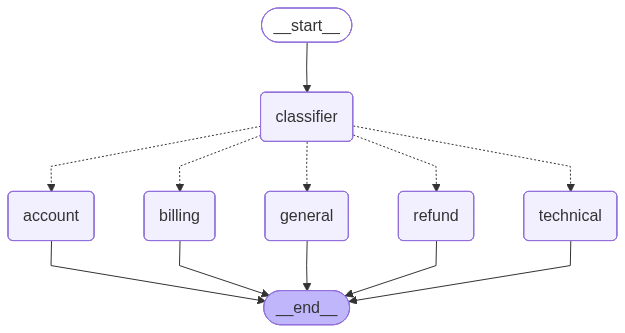

In [7]:
app

In [17]:
billing_query="My payment failed but money was deducted from my account."
technical_query = "I’m getting a 500 error when accessing the dashboard."
refund_query  = "Can I cancel my order and get my money back?"
account_query = "My account is locked after multiple login attempts."
general_query = "Is there a free trial available?"

response = app.invoke({
    "customer_query":general_query,
})

print("="*30)
print(f"{response['query_category'].upper()} REQUEST")
print("="*30)

print()
print("==REQUEST==")
print(response['customer_query'])

print()
print("==RESPONSE==")
print(response['response'])



c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Classifier(category='general', confidence=9), input_type=Classifier])
  return self.__pydantic_serializer__.to_python(


Category general
How Sure are you 1 - 10 9
 GENERAL  HANDLER: Processing general query 
 GENERAL HANDLER: Response Generation
GENERAL REQUEST

==REQUEST==
Is there a free trial available?

==RESPONSE==
Hello!

Thank you for reaching out to us! Yes, we do offer a free trial for our product. This allows you to explore all the features and capabilities without any commitment. You can sign up for the trial directly on our website.

Here’s a link to our free trial sign-up page: [Free Trial Sign-Up](#). 

If you have any questions during your trial or need assistance with anything, please don't hesitate to reach out. Our support team is here to help!

Additionally, I thought you might find our [Getting Started Guide](#) and [FAQ section](#) useful as you explore the product. These resources can help you maximize your experience during the trial period.

If there’s anything else you need, feel free to ask. Enjoy your trial!

Best regards,  
[Your Name]  
Customer Support Team
